In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import pynumdiff
import matplotlib
import matplotlib.colors as mcolors
import colorsys
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
import pandas
import random
import figurefirst as fifi

from matplotlib import patches
from matplotlib.collections import PatchCollection

# the following come from this repository: https://github.com/vanbreugel-lab/braid_tools
from braid_analysis import braid_analysis_plots
from braid_analysis import flymath

2025-04-24 10:00:04,443 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2025-04-24 10:00:04,520 [INFO] Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-04-24 10:00:04,521 [INFO] NumExpr defaulting to 8 threads.


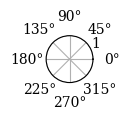

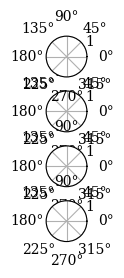

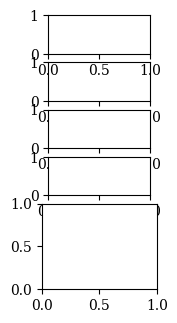

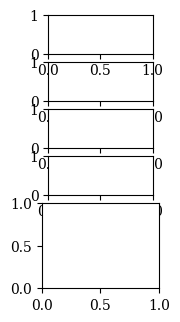

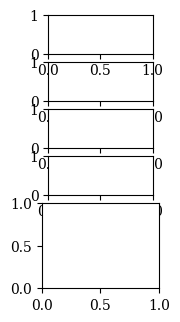

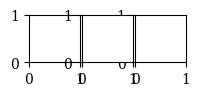

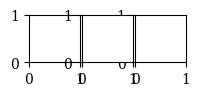

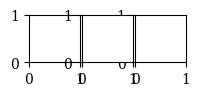

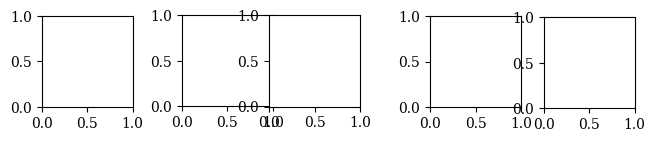

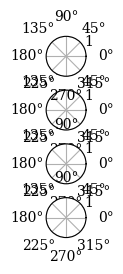

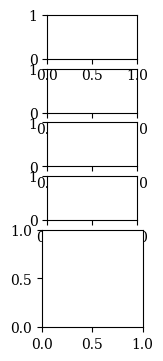

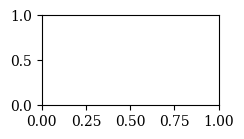

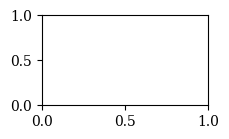

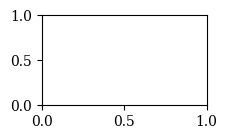

In [3]:
figure = 'unifying_algo_newdraft_with_summary.svg'
layout = fifi.svg_to_axes.FigureLayout(figure, autogenlayers=True, make_mplfigures=True, hide_layers=[])

In [4]:
dt = 0.01
t = np.arange(0, 6.2, dt)

In [5]:
vx = 0.1*np.sin(0.5*2*np.pi*t + np.pi/2) + np.random.normal(0, 0.02, len(t))
vy = 0.1*np.cos(0.5*2*np.pi*t + np.pi/2) + np.random.normal(0, 0.02, len(t))

vx, _ = pynumdiff.smooth_finite_difference.butterdiff(vx, dt, [2, 0.1])
vy, _ = pynumdiff.smooth_finite_difference.butterdiff(vy, dt, [2, 0.1])

v_vec_circle = np.vstack((vx, vy))

x = np.cumsum(vx)*dt
y = np.cumsum(vy)*dt


In [6]:
# Circle

In [7]:
#fig = plt.figure()
#ax = fig.add_subplot(111)
ax = layout.axes[('summary', 'ax_circle')]
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.01)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_xlim(-0.05, 0.07)
ax.set_aspect('equal')

In [8]:
# Cast

In [9]:
rotation_matrix = np.array([[0, -1], [1, 0]])

In [10]:
wind_vector_unit = np.hstack([np.array([[.707], [.707]])]*len(t))

In [11]:
v_vec_cast = np.hstack([np.dot(v_vec_circle[:,i:i+1].T, rotation_matrix@wind_vector_unit[:,i:i+1])*rotation_matrix@wind_vector_unit[:,i:i+1] for i in range(v_vec_circle.shape[1]) ])

In [12]:
v_vec_mostly_cast = v_vec_cast + 0.02*v_vec_circle

In [13]:
x = np.cumsum(v_vec_mostly_cast[0,:])*dt
y = np.cumsum(v_vec_mostly_cast[1,:])*dt

#fig = plt.figure()
#ax = fig.add_subplot(111)
ax = layout.axes[('summary', 'ax_cast_pure')]
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.01)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_xlim(-0.06, 0.08)
ax.set_aspect('equal')

In [14]:
# Cast with upwind bias

In [15]:
v_vec_mostly_cast_upwind_bias = v_vec_cast + 0.02*v_vec_circle + 0.004*wind_vector_unit

In [16]:
x = np.cumsum(v_vec_mostly_cast_upwind_bias[0,:])*dt
y = np.cumsum(v_vec_mostly_cast_upwind_bias[1,:])*dt

#fig = plt.figure()
#ax = fig.add_subplot(111)
ax = layout.axes[('summary', 'ax_cast')]
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.01)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_xlim(-0.06, 0.08)
ax.set_aspect('equal')

In [17]:
# Cast with changing wind

In [18]:
wind_directions = [45]*int(1.5/dt) + [110]*int(1.5/dt) + [170]*int(1.5/dt) + [240]*int((6.2-3*1.5)/dt)
wind_directions = np.hstack(wind_directions)

In [19]:
wind_vector_unit = np.vstack((np.cos(wind_directions*np.pi/180), np.sin(wind_directions*np.pi/180)))

In [20]:
v_vec_cast = np.hstack([np.dot(v_vec_circle[:,i:i+1].T, rotation_matrix@wind_vector_unit[:,i:i+1])*rotation_matrix@wind_vector_unit[:,i:i+1] for i in range(v_vec_circle.shape[1]) ])
v_vec_mostly_cast = v_vec_cast + 0.02*v_vec_circle  + 0.004*wind_vector_unit

In [21]:
norm = mpl.colors.Normalize(vmin=0, vmax=4)
cmap = matplotlib.colormaps['cubehelix']
#cmap = cm.ScalarMappable(norm=norm, cmap=cmap)

# Function to adjust luminosity
def adjust_luminosity(rgb, factor=1.0, lum=0.5):
    # Convert RGB to HLS
    hls = colorsys.rgb_to_hls(*rgb)
    # Keep hue constant, adjust luminosity (lightness)
    return colorsys.hls_to_rgb(hls[0], hls[1]*factor + (1-factor)*lum, hls[2])

# Create the custom colormap with constant luminosity
def create_constant_luminosity_cmap(cmap, n=256, luminosity_factor=0.5):
    colors = cmap(np.linspace(0, 1, n))[:, :3]  # Get RGB values, exclude alpha channel
    adjusted_colors = [adjust_luminosity(color, luminosity_factor) for color in colors]
    return mcolors.ListedColormap(adjusted_colors)

# Create the custom colormap
cubehelix_const_lum = create_constant_luminosity_cmap(cmap, luminosity_factor=0.5)

cmap_ch = cubehelix_const_lum
cmap_ch = cm.ScalarMappable(norm=norm, cmap=cmap_ch)

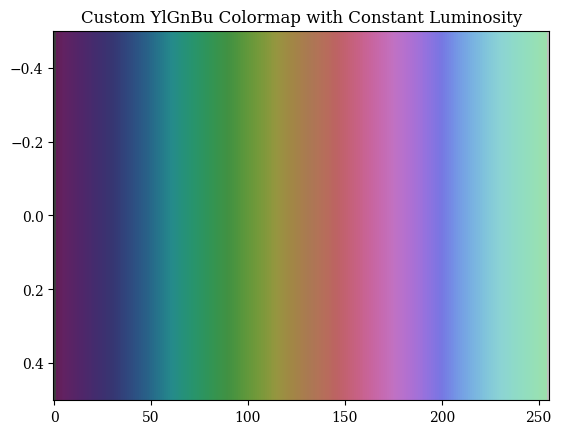

In [22]:
plt.imshow(np.linspace(0, 1, 256)[np.newaxis, :], aspect='auto', cmap=cubehelix_const_lum)
plt.title("Custom YlGnBu Colormap with Constant Luminosity")
plt.show()

In [23]:
x = np.cumsum(v_vec_mostly_cast[0,:])*dt
y = np.cumsum(v_vec_mostly_cast[1,:])*dt

#fig = plt.figure()
#ax = fig.add_subplot(111)
ax = layout.axes[('summary', 'ax_cast_unsteady')]

braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.01)


color = cmap_ch.to_rgba(0)
L = int(1.5/dt)
ax.plot(x[0:L], y[0:L], linewidth=1, color=color)

color = cmap_ch.to_rgba(1)
ax.plot(x[L:L+L], y[L:L+L], linewidth=1, color=color)

color = cmap_ch.to_rgba(2)
ax.plot(x[2*L:3*L], y[2*L:3*L], linewidth=1, color=color)

color = cmap_ch.to_rgba(3)
ax.plot(x[3*L:], y[3*L:], linewidth=1, color=color)

fifi.mpl_functions.adjust_spines(ax, [])
ax.set_xlim(-0.06, 0.08)
ax.set_aspect('equal')

In [24]:
# Cast and circle with changing wind

In [25]:
v_vec_mix = v_vec_cast + 0.5*v_vec_circle  + 0.004*wind_vector_unit
x = np.cumsum(v_vec_mix[0,:])*dt
y = np.cumsum(v_vec_mix[1,:])*dt

#fig = plt.figure()
#ax = fig.add_subplot(111)
ax = layout.axes[('summary', 'ax_mix')]
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.01)

color = cmap_ch.to_rgba(0)
L = int(1.5/dt)
ax.plot(x[0:L], y[0:L], linewidth=1, color=color)

color = cmap_ch.to_rgba(1)
ax.plot(x[L:L+L], y[L:L+L], linewidth=1, color=color)

color = cmap_ch.to_rgba(2)
ax.plot(x[2*L:3*L], y[2*L:3*L], linewidth=1, color=color)

color = cmap_ch.to_rgba(3)
ax.plot(x[3*L:], y[3*L:], linewidth=1, color=color)


fifi.mpl_functions.adjust_spines(ax, [])
ax.set_xlim(-0.06, 0.08)
ax.set_aspect('equal')

In [26]:
layout.append_figure_to_layer(layout.figures['summary'], 'summary', cleartarget=True)
layout.write_svg(figure)